# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [6]:
import pandas as pd

df = pd.read_csv("loan_data.csv")
print(df.shape)
print(df.columns)
df.head()


(45000, 14)
Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


In [12]:
df.groupby('person_gender')['loan_status'].value_counts(normalize=True)


person_gender  loan_status
female         0              0.889720
               1              0.110280
male           0              0.892289
               1              0.107711
Name: proportion, dtype: float64

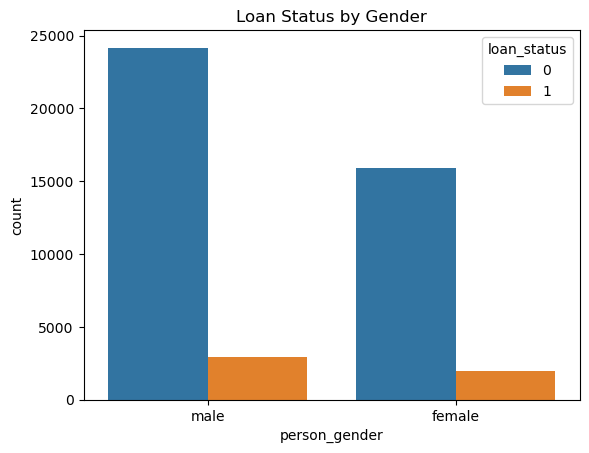

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='person_gender', hue='loan_status')
plt.title("Loan Status by Gender")
plt.show()


<Axes: xlabel='person_education', ylabel='person_income'>

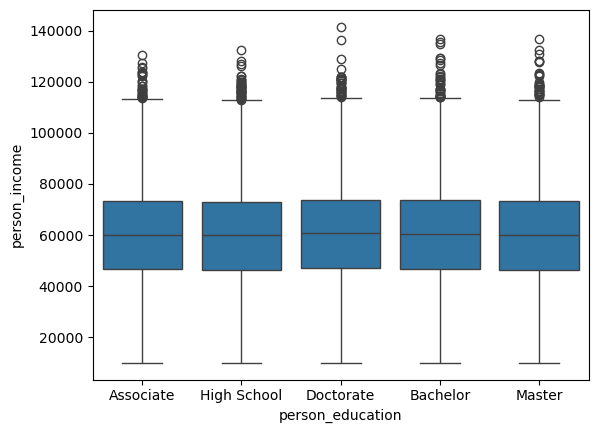

In [20]:
sns.boxplot(data=df, x='person_education', y='person_income')



In [22]:
pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index')


loan_status,0,1
person_home_ownership,,
MORTGAGE,0.986965,0.013035
OWN,0.756529,0.243471
RENT,0.917747,0.082253


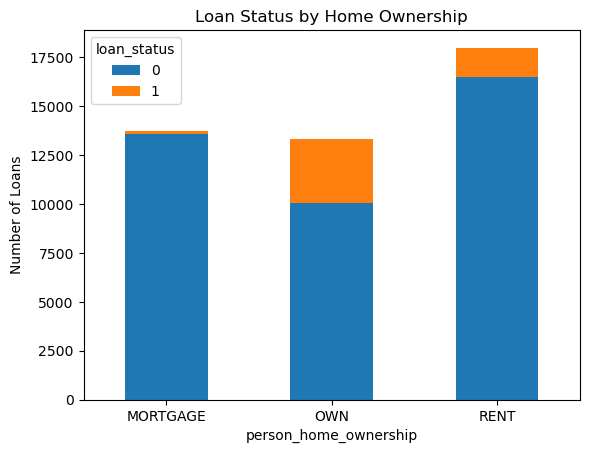

In [48]:
pd.crosstab(df['person_home_ownership'], df['loan_status']).plot(kind='bar', stacked=True, 
        title='Loan Status by Home Ownership', ylabel='Number of Loans')

plt.xticks(rotation=0)
plt.show()


In [50]:
# Create AgeGroup categories
df['AgeGroup'] = 'Unknown'
df.loc[df['person_age'] < 25, 'AgeGroup'] = 'Young (<25)'
df.loc[(df['person_age'] >= 25) & (df['person_age'] < 40), 'AgeGroup'] = 'Adult (25–39)'
df.loc[(df['person_age'] >= 40) & (df['person_age'] < 60), 'AgeGroup'] = 'Middle Age (40–59)'
df.loc[df['person_age'] >= 60, 'AgeGroup'] = 'Senior (60+)'

# Data chart
age_table = pd.crosstab(df['AgeGroup'], df['loan_status']).sort_index()
age_table['Total'] = age_table.sum(axis=1)
print("=== Loan Status by Age Group ===")
display(age_table)  # Excel-like chart


=== Loan Status by Age Group ===


loan_status,0,1,Total
AgeGroup,,,
Adult (25–39),8453,1836,10289
Middle Age (40–59),11260,2302,13562
Senior (60+),17592,120,17712
Young (<25),2802,635,3437


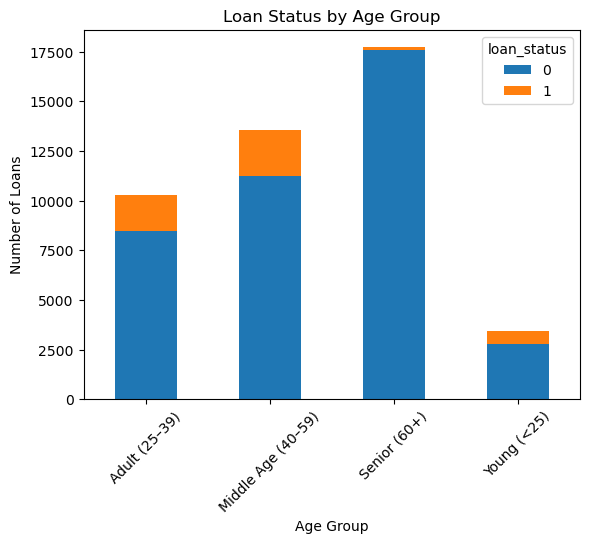

In [52]:
# Graph
age_table.drop(columns='Total').plot(kind='bar', stacked=True,
    title='Loan Status by Age Group', ylabel='Number of Loans')

plt.xticks(rotation=45)
plt.xlabel('Age Group')
plt.legend(title='loan_status')
plt.show()


In [54]:
# Create income buckets by quartiles
q1_inc = df['person_income'].quantile(0.25)
q3_inc = df['person_income'].quantile(0.75)

df['IncomeBucket'] = 'Unknown'
df.loc[df['person_income'] <= q1_inc, 'IncomeBucket'] = f'Low (≤ {q1_inc:.0f})'
df.loc[(df['person_income'] > q1_inc) & (df['person_income'] <= q3_inc), 'IncomeBucket'] = f'Mid ({q1_inc:.0f}–{q3_inc:.0f})'
df.loc[df['person_income'] > q3_inc, 'IncomeBucket'] = f'High (> {q3_inc:.0f})'

# Data chart
income_table = pd.crosstab(df['IncomeBucket'], df['loan_status']).sort_index()
income_table['Total'] = income_table.sum(axis=1)
print("=== Loan Status by Income Level ===")
display(income_table)


=== Loan Status by Income Level ===


loan_status,0,1,Total
IncomeBucket,,,
High (> 73453),8617,2633,11250
Low (≤ 46649),10843,407,11250
Mid (46649–73453),20647,1853,22500


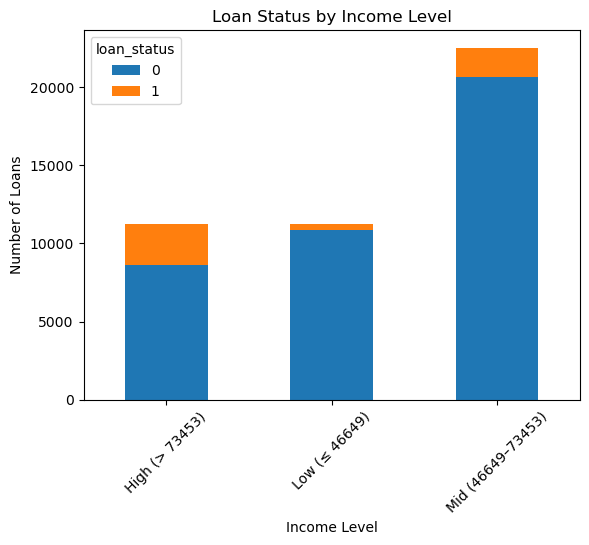

In [56]:
# Graph
income_table.drop(columns='Total').plot(kind='bar', stacked=True,
    title='Loan Status by Income Level', ylabel='Number of Loans')

plt.xticks(rotation=45)
plt.xlabel('Income Level')
plt.legend(title='loan_status')
plt.show()


In [58]:
# Create employment groups
df['EmpExpGroup'] = 'Unknown'
df.loc[df['person_emp_exp'] < 2, 'EmpExpGroup'] = 'New (<2 yrs)'
df.loc[(df['person_emp_exp'] >= 2) & (df['person_emp_exp'] < 10), 'EmpExpGroup'] = 'Mid (2–9 yrs)'
df.loc[df['person_emp_exp'] >= 10, 'EmpExpGroup'] = 'Experienced (10+ yrs)'

# Data chart
emp_table = pd.crosstab(df['EmpExpGroup'], df['loan_status']).sort_index()
emp_table['Total'] = emp_table.sum(axis=1)
print("=== Loan Status by Employment Experience ===")
display(emp_table)


=== Loan Status by Employment Experience ===


loan_status,0,1,Total
EmpExpGroup,,,
Experienced (10+ yrs),26596,3296,29892
Mid (2–9 yrs),10777,1314,12091
New (<2 yrs),2734,283,3017


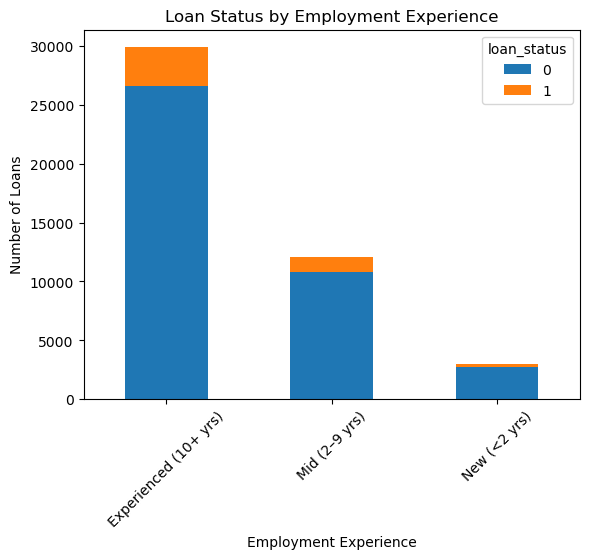

In [60]:
# Graph
emp_table.drop(columns='Total').plot(kind='bar', stacked=True,
    title='Loan Status by Employment Experience', ylabel='Number of Loans')

plt.xticks(rotation=45)
plt.xlabel('Employment Experience')
plt.legend(title='loan_status')
plt.show()


In [62]:
# Create loan amount buckets by quartiles
q1_amt = df['loan_amnt'].quantile(0.25)
q3_amt = df['loan_amnt'].quantile(0.75)

df['LoanAmtBucket'] = 'Unknown'
df.loc[df['loan_amnt'] <= q1_amt, 'LoanAmtBucket'] = f'Small (≤ {q1_amt:.0f})'
df.loc[(df['loan_amnt'] > q1_amt) & (df['loan_amnt'] <= q3_amt), 'LoanAmtBucket'] = f'Medium ({q1_amt:.0f}–{q3_amt:.0f})'
df.loc[df['loan_amnt'] > q3_amt, 'LoanAmtBucket'] = f'Large (> {q3_amt:.0f})'

# Data chart
loan_table = pd.crosstab(df['LoanAmtBucket'], df['loan_status']).sort_index()
loan_table['Total'] = loan_table.sum(axis=1)
print("=== Loan Status by Loan Amount ===")
display(loan_table)


=== Loan Status by Loan Amount ===


loan_status,0,1,Total
LoanAmtBucket,,,
Large (> 20372),10554,696,11250
Medium (9620–20372),19851,2649,22500
Small (≤ 9620),9702,1548,11250


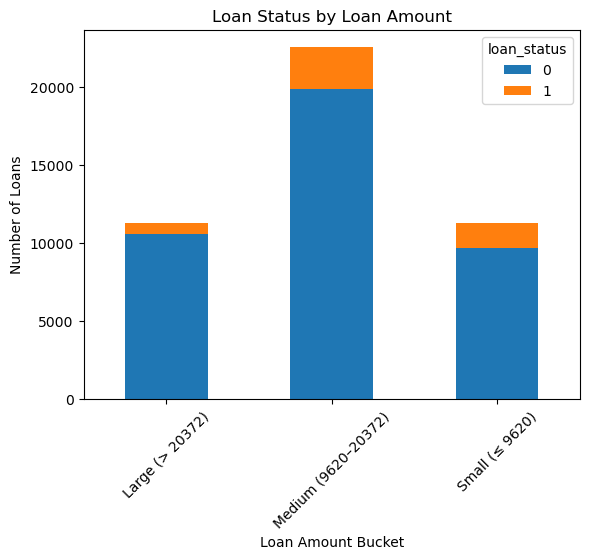

In [64]:
# Graph
loan_table.drop(columns='Total').plot(kind='bar', stacked=True,
    title='Loan Status by Loan Amount', ylabel='Number of Loans')

plt.xticks(rotation=45)
plt.xlabel('Loan Amount Bucket')
plt.legend(title='loan_status')
plt.show()


In [66]:
# Create credit score groups
df['CreditScoreGroup'] = 'Unknown'
df.loc[df['credit_score'] < 580, 'CreditScoreGroup'] = 'Poor (<580)'
df.loc[(df['credit_score'] >= 580) & (df['credit_score'] < 670), 'CreditScoreGroup'] = 'Fair (580–669)'
df.loc[(df['credit_score'] >= 670) & (df['credit_score'] < 740), 'CreditScoreGroup'] = 'Good (670–739)'
df.loc[(df['credit_score'] >= 740) & (df['credit_score'] < 800), 'CreditScoreGroup'] = 'Very Good (740–799)'
df.loc[df['credit_score'] >= 800, 'CreditScoreGroup'] = 'Excellent (800+)'

# Data chart
score_table = pd.crosstab(df['CreditScoreGroup'], df['loan_status']).sort_index()
score_table['Total'] = score_table.sum(axis=1)
print("=== Loan Status by Credit Score ===")
display(score_table)


=== Loan Status by Credit Score ===


loan_status,0,1,Total
CreditScoreGroup,,,
Excellent (800+),1649,360,2009
Fair (580–669),15552,1042,16594
Good (670–739),14051,1998,16049
Poor (<580),3223,217,3440
Very Good (740–799),5632,1276,6908


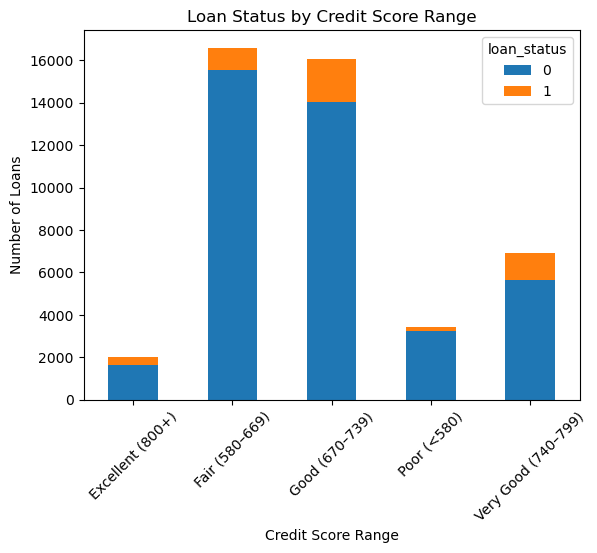

In [68]:
# Graph
score_table.drop(columns='Total').plot(kind='bar', stacked=True,
    title='Loan Status by Credit Score Range', ylabel='Number of Loans')

plt.xticks(rotation=45)
plt.xlabel('Credit Score Range')
plt.legend(title='loan_status')
plt.show()


**Q1. Which features seem to drive the model's decision to grant a loan?**

The visualizations show that credit score, income, employment experience, and loan amount have the strongest influence on loan status. In the credit score chart, applicants with “Good” to “Excellent” scores were overwhelmingly approved, while those with “Poor” scores were usually denied. The income chart showed that higher-income groups had much higher approval rates. Employment experience also mattered: borrowers with 10+ years of work had more approvals, while those with fewer than 2 years were denied more often. Finally, the loan amount chart showed smaller loans were approved more often than large ones, which carried more risk.

**Q2. Which features seem unrelated?**

The charts for age and sex showed much weaker patterns. In the age visualization, approval rates across groups were fairly similar, with only a small advantage for middle-aged borrowers. In the sex chart, male and female applicants had nearly identical approval and denial rates. These features appear to be only weakly related or unrelated to loan status compared to the stronger drivers like credit score and income.

**Q3. Should the financial institution be concerned about potential legal trouble?**

Yes. Even though age and sex did not strongly affect approval rates in the visualizations, they are protected categories under lending laws such as the Equal Credit Opportunity Act. Using them in loan decisions could still lead to discrimination claims. To stay compliant, the institution should rely on legitimate predictors like credit score, income, employment history, and loan amount, and avoid using age or sex directly in their decision-making process.